<a href="https://colab.research.google.com/github/MichelleLea26/PBA-carousell-SentimentAnalysis/blob/main/Week%202-3/%20EDA_ReviewCarousellApp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis Carousell App Review

**Import Library**

In [1]:
!pip install wordcloud nltk -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

In [3]:
nltk.download('stopwords')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Load Dataset**

In [4]:
from google.colab import files
import io

print("Silakan upload file 'carousell_reviews_filtered.csv':")
uploaded = files.upload()

# Mengambil nama file dan membaca data
nama_file = list(uploaded.keys())[0]
df_eda = pd.read_csv(io.BytesIO(uploaded[nama_file]))

print(f"\nData '{nama_file}' berhasil dimuat!")

Silakan upload file 'carousell_reviews_filtered.csv':


Saving carousell_reviews.csv to carousell_reviews.csv

Data 'carousell_reviews.csv' berhasil dimuat!


**Data Overview**

In [5]:
print("=== INFO DATASET ===")
df_eda.info()

print("\n=== 5 DATA TERATAS ===")
display(df_eda.head())

# Mengubah tipe data tanggal (at) menjadi format datetime
df_eda['at'] = pd.to_datetime(df_eda['at'], errors='coerce')

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21895 entries, 0 to 21894
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              21895 non-null  object
 1   userName              21895 non-null  object
 2   userImage             21895 non-null  object
 3   content               21894 non-null  object
 4   score                 21895 non-null  int64 
 5   thumbsUpCount         21895 non-null  int64 
 6   reviewCreatedVersion  16304 non-null  object
 7   at                    21895 non-null  object
 8   replyContent          905 non-null    object
 9   repliedAt             905 non-null    object
 10  appVersion            16304 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.8+ MB

=== 5 DATA TERATAS ===


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,ef1a0eae-8c5b-42cb-899f-8b50675c5caa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aku follow 48 seller, tapi ternyata di menu ""M...",4,0,2.436.14,2026-05-02 04:22:06,NaN,NaN,2.436.14
1,6872e98b-b3d5-4f11-a40f-b936b39554c4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi nya keren gacor baru upload udah ada ...,5,0,2.449.7,2026-05-01 05:00:14,NaN,NaN,2.449.7
2,ba4b550d-9a7e-4855-8208-899bc7a1a8ac,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mau reset password & login di device baru fail...,1,0,2.452.8,2026-05-01 01:30:32,NaN,NaN,2.452.8
3,3d71ba55-05db-41b4-b03e-572527d94af7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,rekomended,5,0,2.451.8,2026-04-30 15:33:08,NaN,NaN,2.451.8
4,9195c5b3-8beb-42eb-9cb4-05eb99a52de8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Nice app,5,0,2.451.8,2026-04-30 10:26:10,NaN,NaN,2.451.8


**Missing Values Analysis**

In [6]:
print("=== JUMLAH MISSING VALUES PER KOLOM ===")
missing_values = df_eda.isnull().sum()
print(missing_values)

=== JUMLAH MISSING VALUES PER KOLOM ===
reviewId                    0
userName                    0
userImage                   0
content                     1
score                       0
thumbsUpCount               0
reviewCreatedVersion     5591
at                          0
replyContent            20990
repliedAt               20990
appVersion               5591
dtype: int64


/tmp/ipykernel_17616/453458960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')


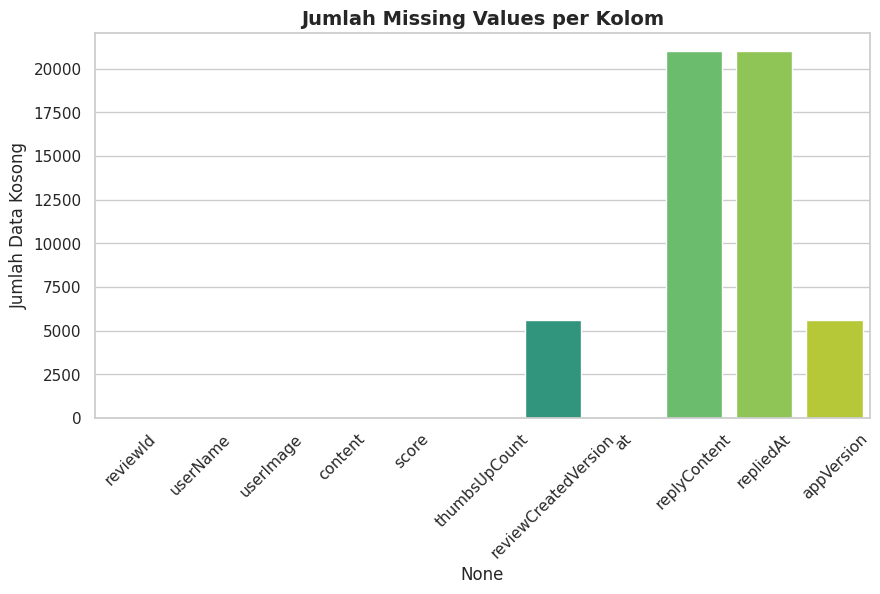

In [7]:
# Visualisasi Missing Values
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
plt.title('Jumlah Missing Values per Kolom', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Jumlah Data Kosong')
plt.show()

**Score Distribution**

/tmp/ipykernel_17616/1000987449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_eda, x='score', palette='RdYlGn')


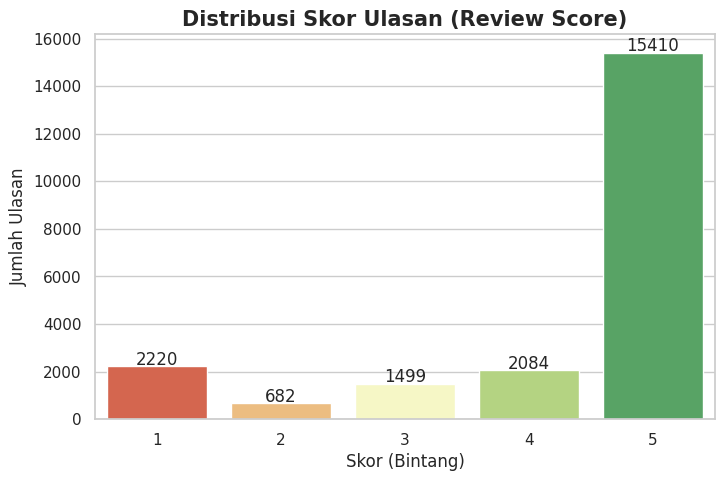

In [8]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_eda, x='score', palette='RdYlGn')
plt.title('Distribusi Skor Ulasan (Review Score)', fontsize=15, fontweight='bold')
plt.xlabel('Skor (Bintang)')
plt.ylabel('Jumlah Ulasan')

# Menambahkan angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.4, p.get_height() + 50), ha='center')

plt.show()

**Temporal Analysis**

In [9]:
# Membuat kolom Tahun-Bulan untuk agregasi
df_eda['year_month'] = df_eda['at'].dt.to_period('M')

# Menghitung volume review dan rata-rata skor per bulan
trend_data = df_eda.groupby('year_month').agg(
    review_count=('content', 'count'),
    avg_score=('score', 'mean')
).reset_index()

# Mengubah format year_month kembali ke string agar mudah diplot
trend_data['year_month'] = trend_data['year_month'].astype(str)

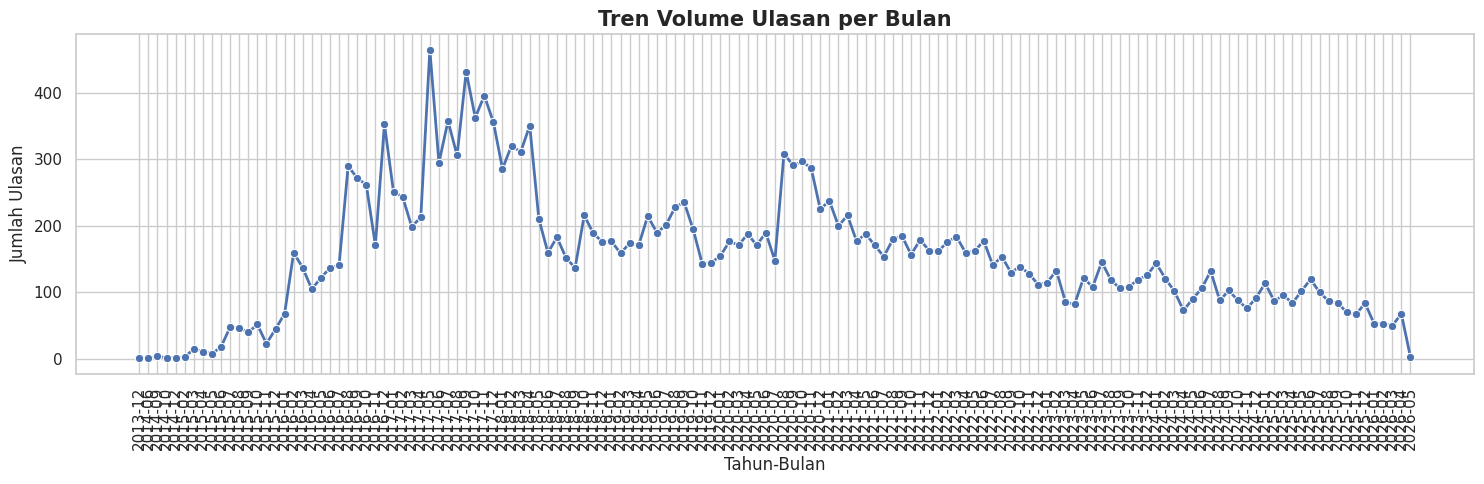

In [10]:
# Plot 1: Tren Volume Ulasan
plt.figure(figsize=(15, 5))
sns.lineplot(data=trend_data, x='year_month', y='review_count', marker='o', color='b', linewidth=2)
plt.title('Tren Volume Ulasan per Bulan', fontsize=15, fontweight='bold')
plt.xticks(rotation=90)
plt.xlabel('Tahun-Bulan')
plt.ylabel('Jumlah Ulasan')
plt.tight_layout()
plt.show()

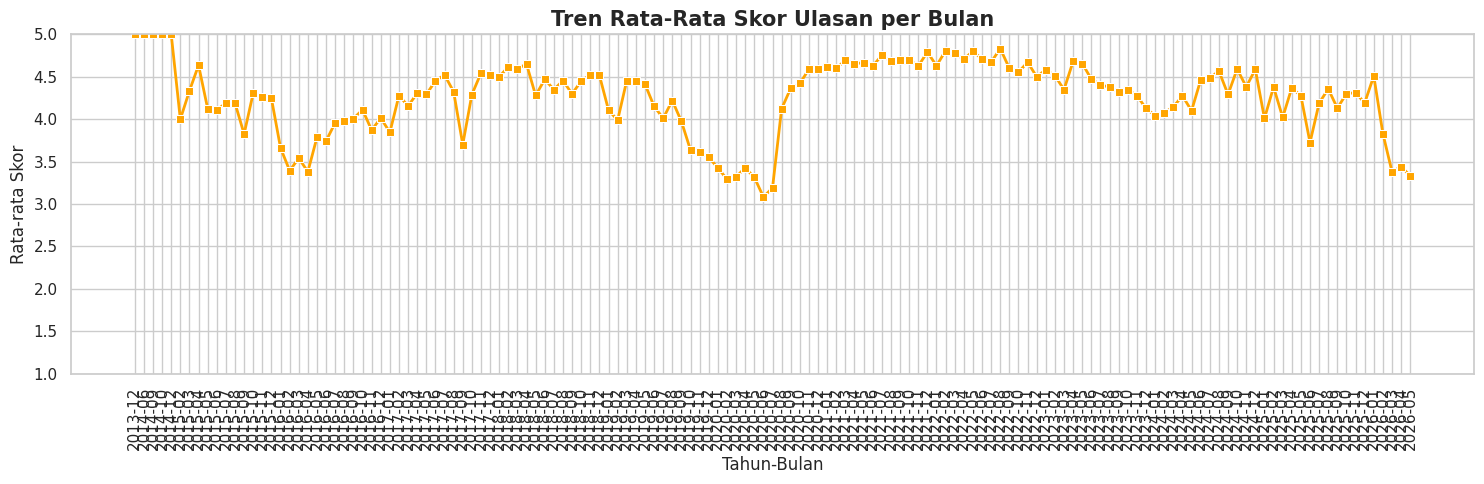

In [11]:
# Plot 2: Tren Rata-rata Skor
plt.figure(figsize=(15, 5))
sns.lineplot(data=trend_data, x='year_month', y='avg_score', marker='s', color='orange', linewidth=2)
plt.title('Tren Rata-Rata Skor Ulasan per Bulan', fontsize=15, fontweight='bold')
plt.xticks(rotation=90)
plt.ylim(1, 5) # Set batas sumbu Y dari 1 sampai 5 (karena skor maksimal 5)
plt.xlabel('Tahun-Bulan')
plt.ylabel('Rata-rata Skor')
plt.tight_layout()
plt.show()

**Text Analysis**

In [12]:
# 1. Melabeli Sentimen
def get_sentiment(score):
    if score <= 2: return 'Negative'
    elif score == 3: return 'Neutral'
    else: return 'Positive'

df_eda['sentiment'] = df_eda['score'].apply(get_sentiment)

# 2. Persiapan Stopwords (Kata yang diabaikan karena tidak bermakna)
stop_words = set(stopwords.words('indonesian'))
custom_stops = {'yg', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'untuk', 'dengan',
                'carousell', 'aplikasi', 'app', 'nya', 'ada', 'ga', 'gk', 'gak'}
stop_words.update(custom_stops)

# Fungsi pembersih teks sederhana untuk EDA
def clean_text_eda(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Buang angka & tanda baca
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Terapkan pembersihan
df_eda['clean_text'] = df_eda['content'].apply(clean_text_eda)

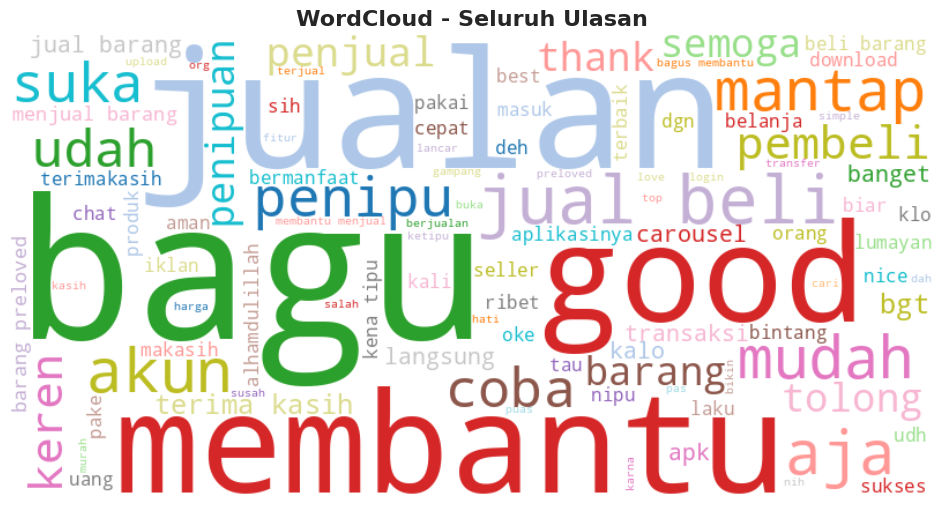

In [13]:
text_all = ' '.join(df_eda['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab20', max_words=100).generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Seluruh Ulasan', fontsize=16, fontweight='bold')
plt.show()

**Top Words**

/tmp/ipykernel_17616/320448544.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pos, y='Word', x='Count', ax=axes[0], palette='Greens_r')
/tmp/ipykernel_17616/320448544.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_neg, y='Word', x='Count', ax=axes[1], palette='Reds_r')


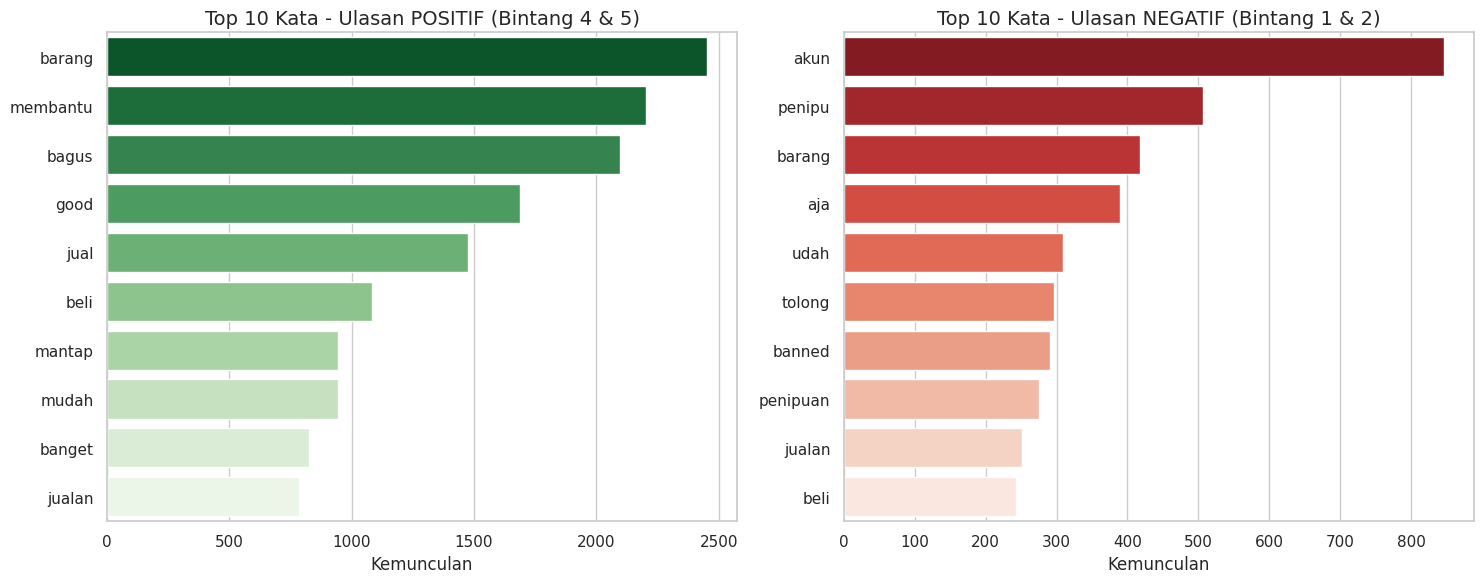

In [14]:
# Memisahkan teks berdasarkan sentimen
text_pos = ' '.join(df_eda[df_eda['sentiment'] == 'Positive']['clean_text']).split()
text_neg = ' '.join(df_eda[df_eda['sentiment'] == 'Negative']['clean_text']).split()

# Menghitung 10 kata terbanyak
top_pos = Counter(text_pos).most_common(10)
top_neg = Counter(text_neg).most_common(10)

# Membuat DataFrame untuk Plotting
df_pos = pd.DataFrame(top_pos, columns=['Word', 'Count'])
df_neg = pd.DataFrame(top_neg, columns=['Word', 'Count'])

# Plotting secara bersebelahan
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Positif
sns.barplot(data=df_pos, y='Word', x='Count', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Kata - Ulasan POSITIF (Bintang 4 & 5)', fontsize=14)
axes[0].set_xlabel('Kemunculan')
axes[0].set_ylabel('')

# Plot Negatif
sns.barplot(data=df_neg, y='Word', x='Count', ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Kata - Ulasan NEGATIF (Bintang 1 & 2)', fontsize=14)
axes[1].set_xlabel('Kemunculan')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()